In [1]:
import sys
sys.path.insert(0,'../g3algo/')
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('TkAgg')
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator, AutoLocator
from matplotlib import rcParams
from scipy.optimize import curve_fit
from scipy.stats import chisquare
import foftools as fof
import iterativecombination as ic
from scipy import odr
from seaborn import kdeplot
rcParams['axes.labelsize'] = 9
rcParams['xtick.labelsize'] = 9
rcParams['ytick.labelsize'] = 9
rcParams['legend.fontsize'] = 9
rcParams['font.family'] = 'sans-serif'
rcParams['grid.color'] = 'k'
rcParams['grid.linewidth'] = 0.2
my_locator = MaxNLocator(6)
singlecolsize = (3.3522420091324205, 2.0717995001590714)
doublecolsize = (7.500005949910059, 4.3880449973709)

%matplotlib inline
resolveshadecolor='#7AA8E7'
resolvemarkercolor='#3D5473'
ecoshadecolor='#E7B97A'
ecomarkercolor='#a66d1e'

In [2]:
resolve=pd.read_csv("../resolve_and_eco/RESOLVEdata_G3catalog_luminosity.csv")
resolve=resolve[(resolve.g3grpcz_l>4500)&(resolve.g3grpcz_l<7000)&(resolve.fl_insample==1)&(resolve.g3fc_l==1)]
eco=pd.read_csv("../resolve_and_eco/ECOdata_G3catalog_luminosity.csv")
eco=eco[(eco.g3grpcz_l>3000)&(eco.g3grpcz_l<7000)&(eco.absrmag<-17.33)&(eco.g3fc_l==1)&(eco.resname=='notinresolve')]
binnedhihm = pd.read_csv("resolve_eco_hihm.csv")
binnedfrac = pd.read_csv("resolve_eco_mhiovermhalo.csv")

In [3]:
print(len(eco))

5853


In [4]:
def hihalomodel(Mh, M0, Mmin, alpha):
    return M0*((Mh/Mmin)**alpha)*np.exp(-1*Mmin/Mh)

In [5]:
from center_binned_stats import center_binned_stats as cbs

In [6]:
binvalues = [11,11.15,11.3,11.45,11.6,11.75,12.,12.25,12.5,12.75,12.95,13.3,14.75]

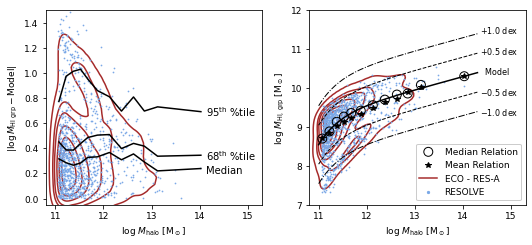

In [7]:
ecologmh=eco.g3logmh_l.to_numpy()
ecogrpmhi=eco.g3grpmhi_l.to_numpy()
resolvelogmh=resolve.g3logmh_l.to_numpy()
resolvegrpmhi=resolve.g3grpmhi_l.to_numpy()

fig,axs=plt.subplots(ncols=2,figsize=(doublecolsize[0],0.8*doublecolsize[1]))
#axs[1].scatter(ecologmh,ecogrpmhi,color='brown',s=0.5)
axs[1].scatter(resolvelogmh,resolvegrpmhi,color=resolveshadecolor,s=0.5)
kdeplot(ecologmh,y=ecogrpmhi,color='brown',ax=axs[1],zorder=0,levels=7)

popthi=[10**9.357,10**11.229,0.338]
tx=np.linspace(10**11.,10**14.3,10000)
modelvals=np.log10(hihalomodel(tx,*popthi))
# axs[1].errorbar(binnedhihm.logmh,binnedhihm.ecomhigrp,yerr=[binnedhihm.ecomhigrp_staterrlo,binnedhihm.ecomhigrp_staterrhi],\
#                markeredgecolor='k',markerfacecolor='None',ls='None',marker='o',markersize=5,label='Median')
axs[1].scatter(binnedhihm.logmh,binnedhihm.ecomhigrp,marker='o',facecolor='None',edgecolor='k',label='Median Relation',s=80)
mean,bc,_,_ = cbs(ecologmh,ecogrpmhi,np.average,bins=binvalues)
axs[1].plot(bc,mean,'k*', label='Mean Relation')
axs[1].plot(np.log10(tx),modelvals,color='k')
axs[1].plot(np.log10(tx),modelvals-1,color='k',linestyle='-.', linewidth=1)
axs[1].plot(np.log10(tx),modelvals+1,color='k',linestyle='-.', linewidth=1)
axs[1].plot(np.log10(tx),modelvals-0.5,color='k',linestyle='--', linewidth=1)
axs[1].plot(np.log10(tx),modelvals+0.5,color='k',linestyle='--', linewidth=1)
axs[1].annotate('$+1.0$ dex',xy=(14.35,11.4),fontsize=8)
axs[1].annotate('$+$0.5 dex',xy=(14.35,10.85),fontsize=8)
axs[1].annotate('  Model', xy=(14.35,10.35),fontsize=8)
axs[1].annotate('$-$1.0 dex',xy=(14.35,9.3),fontsize=8)
axs[1].annotate('$-$0.5 dex',xy=(14.35,9.8),fontsize=8)
axs[1].set_ylim(7,12)
axs[1].plot([12,13],[-99,-98],color='brown',label='ECO - RES-A')
axs[1].scatter(12,-99,color=resolveshadecolor,s=5,label='RESOLVE')
axs[1].set_ylabel(r"log $M_{\rm HI,\, grp}$ [$\rm M_\odot$]")
axs[1].set_xlabel(r"log $M_{\rm halo}$ [$\rm M_\odot$]")
axs[1].legend(loc='lower right', framealpha=1)
axs[1].set_xlim(10.8,15.3)

popthieco_wo_resa=[10**9.427,10**11.292,0.31]
popthiresolve = [10**9.473,10**11.298,0.259]
binvalues = [11,11.15,11.3,11.45,11.6,11.75,12.,12.25,12.5,12.75,12.95,13.3,14.75]
residuals=np.abs(ecogrpmhi - np.log10(hihalomodel(10**ecologmh,*popthieco_wo_resa)))
resresiduals=np.abs(resolvegrpmhi - np.log10(hihalomodel(10**resolvelogmh,*popthi)))
medresid,bc,_,_=cbs(ecologmh,residuals,'median',bins=binvalues)
#axs[0].scatter(ecologmh, residuals,color='brown',s=0.5)
kdeplot(ecologmh,y=residuals,color='brown', ax=axs[0], zorder=0, levels=7)
axs[0].scatter(resolvelogmh,resresiduals,color=resolveshadecolor,s=0.5)
axs[0].plot(bc,medresid,'k')
axs[0].annotate("Median",xy=(max(bc)+0.1,medresid[-1]-0.04))
resid95,bc,_,_=cbs(ecologmh,residuals,lambda x:np.nanpercentile(x,95),bins=binvalues)
axs[0].plot(bc,resid95,color='k')
axs[0].annotate(r"95$^{\rm th}$ %tile",xy=(max(bc)+0.1,resid95[-1]-0.04))
resid68,bc,_,_=cbs(ecologmh,residuals,lambda x:np.nanpercentile(x,68),bins=binvalues)
axs[0].plot(bc,resid68,color='k')
axs[0].annotate(r"68$^{\rm th}$ %tile",xy=(max(bc)+0.1,resid68[-1]-0.04))
axs[0].set_ylim(-0.05,1.5)
axs[0].set_ylabel(r"$\left\|\log M_{\rm HI\,\, grp} - {\rm Model}\right\|$")
axs[0].set_xlabel(r"log $M_{\rm halo}$ [$\rm M_\odot$]")
axs[0].set_xlim(10.8,15.3)
plt.tight_layout()
plt.savefig("../figures/RESOLVE_ECO_HIHMscatter.pdf",dpi=300)
plt.show()

In [8]:
binnedhihm.ecomhigrp, mean

(0      8.701154
 1      8.884927
 2      9.133225
 3      9.266022
 4      9.357015
 5      9.418468
 6      9.558697
 7      9.701481
 8      9.831682
 9      9.859017
 10    10.080391
 11    10.302805
 Name: ecomhigrp, dtype: float64,
 array([ 8.70319886,  8.83980323,  9.02589558,  9.12469403,  9.22273319,
         9.33614804,  9.49677077,  9.64743934,  9.72300897,  9.89906452,
        10.01536367, 10.30939132]))

8.701154378856762
8.703198860221645


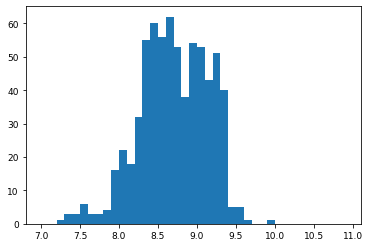

In [20]:
sel = (ecologmh<11.15)
plt.figure()
plt.hist(ecogrpmhi[sel],bins=np.arange(7,11,0.1))
print(np.median(ecogrpmhi[sel]))
print(np.mean(ecogrpmhi[sel]))
plt.show()

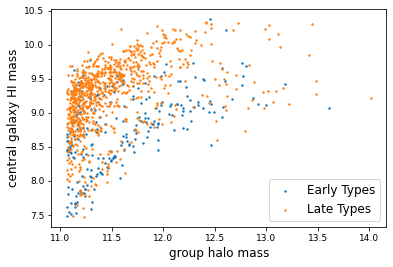

In [30]:
plt.figure()
sel = (resolve.morphel=='E')
plt.scatter(resolve.g3logmh_l[sel],resolve.logmgas[sel], label='Early Types', s=2)
sel = (resolve.morphel=='L')
plt.scatter(resolve.g3logmh_l[sel],resolve.logmgas[sel], label='Late Types',s=2)
plt.xlabel("group halo mass",fontsize=12)
plt.ylabel("central galaxy HI mass",fontsize=12)
plt.legend(loc='best',fontsize=12)
plt.show()

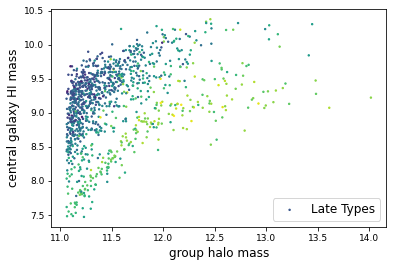

In [32]:
plt.figure()
plt.scatter(resolve.g3logmh_l,resolve.logmgas, c=resolve.modelu_r, label='Late Types',s=2)
plt.xlabel("group halo mass",fontsize=12)
plt.ylabel("central galaxy HI mass",fontsize=12)
plt.legend(loc='best',fontsize=12)
plt.show()

In [33]:
from scipy.io import readsav

In [35]:
idl = readsav("/srv/one/resolve/database_internal/merged_idl_catalog/stable/resolvecatalog.dat")

In [63]:
flyby = np.float64(idl['flyby'])
groupmass = np.float64(idl['groupmass'])
himass = np.float64(idl['mgas'])
central = np.float64(idl['central'])

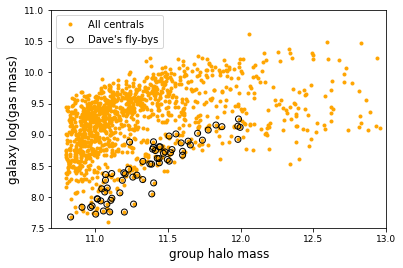

In [70]:
sel = (central>0)&(groupmass>10.8)
plt.figure()
plt.plot(groupmass[sel],np.log10(himass[sel]),'.',color='orange',zorder=0, label='All centrals')
sel = (flyby>0)&(groupmass>10.8)
plt.scatter(groupmass[sel],np.log10(himass[sel]),edgecolor='k', facecolor='None', label="Dave's fly-bys")
plt.xlim(10.7,13)
plt.ylim(7.5,11)
plt.legend(loc='best',fontsize=10)
plt.xlabel("group halo mass",fontsize=12)
plt.ylabel("galaxy log(gas mass)",fontsize=12)
plt.show()

In [54]:
resolve.logmh.min()

10.8619